
# API Token from Kaggle

In [112]:
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_9acc6ba84d7672afea5cecf0fb226318"

In [113]:

!kaggle datasets download -d cooperunion/cardataset

!unzip -o cardataset.zip


!ls -lh data.csv

Dataset URL: https://www.kaggle.com/datasets/cooperunion/cardataset
License(s): unknown
cardataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  cardataset.zip
  inflating: data.csv                
-rw-r--r-- 1 root root 1.5M Sep 20  2019 data.csv


In [114]:
import pandas as pd

df = pd.read_csv("data.csv")
print("Data Shape:", df.shape)


Data Shape: (11914, 16)


In [115]:
df.iloc[:]

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920


# Handle Missing Values

In [116]:

print("--- Data Info ---")
df.info()

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: f

# Clean Data & Preprocessing

In [117]:
import pandas as pd
import numpy as np


df.columns = df.columns.str.lower().str.replace(' ', '_')



duplicates_count = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed duplicate rows: {duplicates_count}")

df = df.drop(columns=['market_category'])


missing_before = df.isnull().sum().sum()
df = df.dropna(
    subset=[
        'engine_hp',
        'engine_cylinders',
        'number_of_doors',
        'engine_fuel_type',
    ]
).reset_index(drop=True)
print(
    f"Handled missing values successfully (resolved {missing_before - df.isnull().sum().sum()} missing entries)"
)


df['number_of_doors'] = df['number_of_doors'].astype(int)
df['engine_cylinders'] = df['engine_cylinders'].astype(int)

df['car_age'] = 2024 - df['year']
df = df.drop(columns=['year'])

df = df[df['msrp'] > 0].reset_index(drop=True)

print("\n--- Summary After Data Cleaning ---")
print("Data Shape After Cleaning (Rows, Columns):", df.shape)
print("Total Remaining Missing Values:", df.isnull().sum().sum())
df.head(5)

Removed duplicate rows: 715
Handled missing values successfully (resolved 108 missing entries)

--- Summary After Data Cleaning ---
Data Shape After Cleaning (Rows, Columns): (11097, 15)
Total Remaining Missing Values: 0


,make,model,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp,car_age
0,BMW,1 Series M,premium unleaded (required),335.0,6,MANUAL,rear wheel drive,2,Compact,Coupe,26,19,3916,46135,13
1,BMW,1 Series,premium unleaded (required),300.0,6,MANUAL,rear wheel drive,2,Compact,Convertible,28,19,3916,40650,13
2,BMW,1 Series,premium unleaded (required),300.0,6,MANUAL,rear wheel drive,2,Compact,Coupe,28,20,3916,36350,13
3,BMW,1 Series,premium unleaded (required),230.0,6,MANUAL,rear wheel drive,2,Compact,Coupe,28,18,3916,29450,13
4,BMW,1 Series,premium unleaded (required),230.0,6,MANUAL,rear wheel drive,2,Compact,Convertible,28,18,3916,34500,13


In [118]:
df.dtypes

,0
make,object
model,object
engine_fuel_type,object
engine_hp,float64
engine_cylinders,int64
transmission_type,object
driven_wheels,object
number_of_doors,int64
vehicle_size,object
vehicle_style,object


In [119]:

drop_cols = ["model", "city_mpg", "popularity"]
df_selected = df.drop(columns=drop_cols).copy()

print(f"Reduced number of columns from {df.shape[1]} to {df_selected.shape[1]}")

print("\n--- Features Retained for Model Training ---")
print(list(df_selected.columns))


numeric_features = [
    "engine_hp",
    "engine_cylinders",
    "number_of_doors",
    "highway_mpg",
    "car_age",
]

categorical_features = [
    "make",
    "engine_fuel_type",
    "transmission_type",
    "driven_wheels",
    "vehicle_size",
    "vehicle_style",
]

print(
    f"\nNumeric features ({len(numeric_features)} columns): {numeric_features}"
)
print(
    f"Categorical features ({len(categorical_features)} columns): {categorical_features}"
)

Reduced number of columns from 15 to 12

--- Features Retained for Model Training ---
['make', 'engine_fuel_type', 'engine_hp', 'engine_cylinders', 'transmission_type', 'driven_wheels', 'number_of_doors', 'vehicle_size', 'vehicle_style', 'highway_mpg', 'msrp', 'car_age']

Numeric features (5 columns): ['engine_hp', 'engine_cylinders', 'number_of_doors', 'highway_mpg', 'car_age']
Categorical features (6 columns): ['make', 'engine_fuel_type', 'transmission_type', 'driven_wheels', 'vehicle_size', 'vehicle_style']


# Boxplot for Visualizing Outliers in Numerical Features

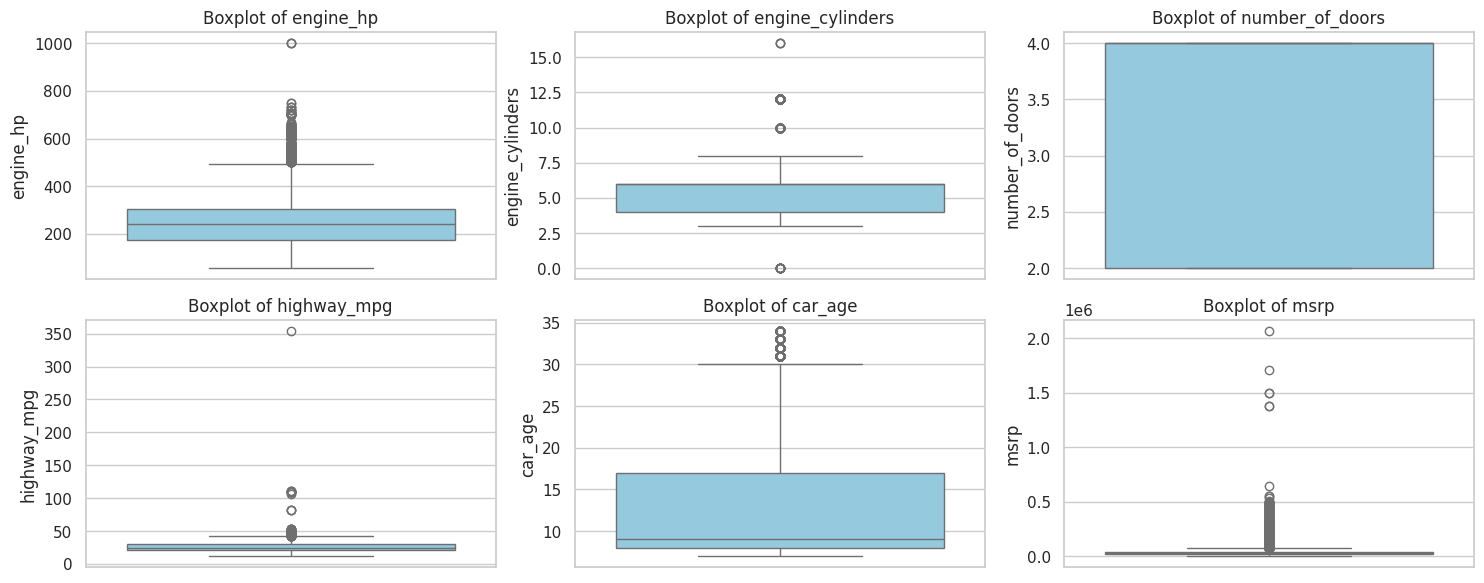

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))
for i, col in enumerate(numeric_features + ["msrp"], 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_selected[col], color="skyblue")
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

# Handling Outliers via Domain Knowledge & Interquartile Range (IQR)

In [121]:
initial_rows = len(df_selected)



df_clean = df_selected[
    (df_selected["msrp"] >= 2000)
    & (df_selected["msrp"] <= 200000)
    & (df_selected["highway_mpg"] <= 60)
    & (df_selected["engine_hp"] <= 750)
].copy()


for col in ["highway_mpg", "engine_hp"]:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_clean = df_clean[
        (df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)
    ]

df_clean = df_clean.reset_index(drop=True)
dropped_rows = initial_rows - len(df_clean)

print(f"Total outliers removed: {dropped_rows} rows")
print(
    f"Remaining data for training: {len(df_clean)} rows (out of {initial_rows})"
)

Total outliers removed: 688 rows
Remaining data for training: 10409 rows (out of 11097)


In [122]:

print(df_clean[["engine_hp", "highway_mpg", "msrp"]].describe())

          engine_hp   highway_mpg           msrp
count  10409.000000  10409.000000   10409.000000
mean     238.513498     26.297339   32353.111154
std       84.924862      5.867817   21952.458076
min       55.000000     12.000000    2000.000000
25%      170.000000     22.000000   20995.000000
50%      227.000000     26.000000   29785.000000
75%      295.000000     30.000000   40685.000000
max      485.000000     42.000000  199054.000000


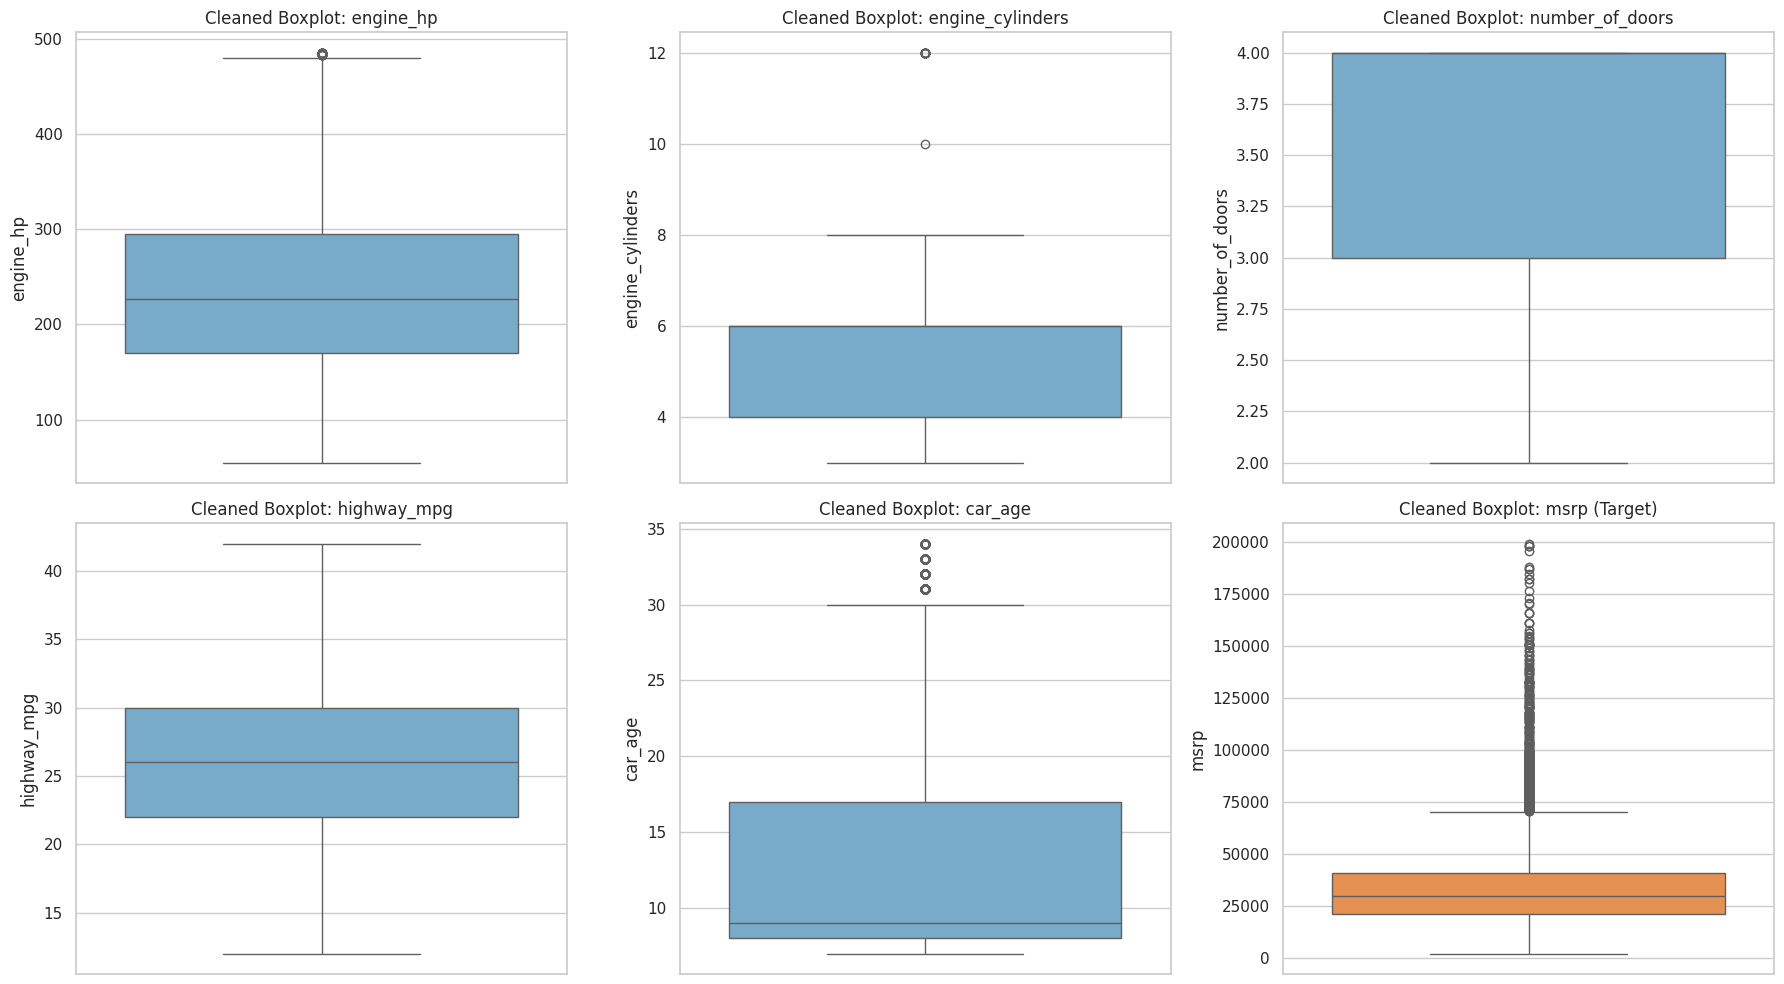

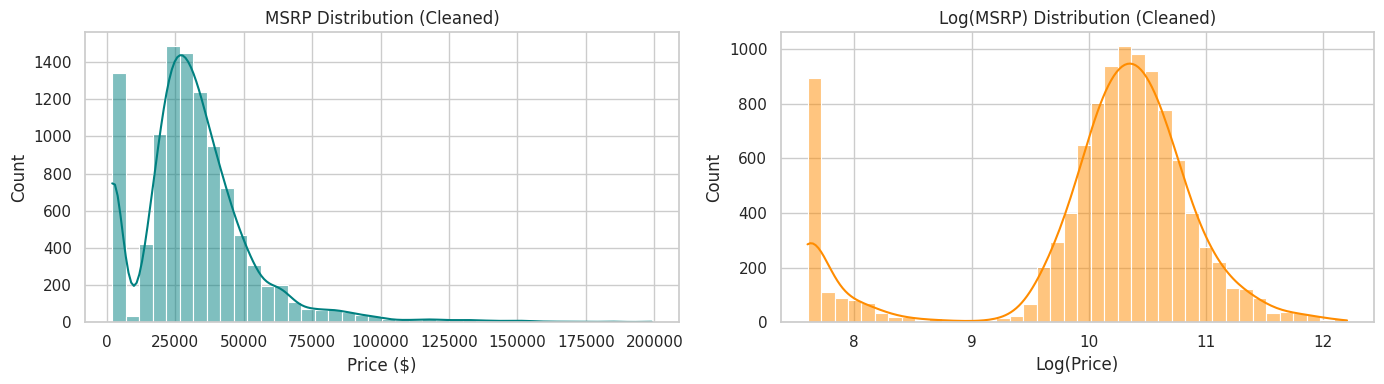

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))


for idx, col in enumerate(numeric_features):
    row, col_idx = divmod(idx, 3)
    sns.boxplot(y=df_clean[col], ax=axes[row, col_idx], color="#6baed6")
    axes[row, col_idx].set_title(f"Cleaned Boxplot: {col}", fontsize=12)


sns.boxplot(y=df_clean["msrp"], ax=axes[1, 2], color="#fd8d3c")
axes[1, 2].set_title("Cleaned Boxplot: msrp (Target)", fontsize=12)

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
sns.histplot(df_clean["msrp"], kde=True, color="teal", bins=40)
plt.title("MSRP Distribution (Cleaned)")
plt.xlabel("Price ($)")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df_clean["msrp"]), kde=True, color="darkorange", bins=40)
plt.title("Log(MSRP) Distribution (Cleaned)")
plt.xlabel("Log(Price)")

plt.tight_layout()
plt.show()

# Data Transformation

In [124]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


X = df_clean.drop(columns=['msrp'])
y = np.log1p(df_clean['msrp'])


numeric_features = ['engine_hp', 'engine_cylinders', 'number_of_doors', 'highway_mpg', 'car_age']
categorical_features = ['make', 'engine_fuel_type', 'transmission_type', 'driven_wheels', 'vehicle_size', 'vehicle_style']


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)


X_transformed = preprocessor.fit_transform(X)


num_cols = numeric_features
cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
all_features_transformed = num_cols + cat_cols

X_transformed_df = pd.DataFrame(X_transformed, columns=all_features_transformed)

print(f"Feature dimensions before transformation: {X.shape}")
print(f"Feature dimensions after transformation: {X_transformed_df.shape}")
X_transformed_df.iloc[:5, :8]

Feature dimensions before transformation: (10409, 11)
Feature dimensions after transformation: (10409, 80)


,engine_hp,engine_cylinders,number_of_doors,highway_mpg,car_age,make_Acura,make_Alfa Romeo,make_Aston Martin
0,1.136194,0.341501,-1.734845,-0.050675,-0.067165,0.0,0.0,0.0
1,0.724045,0.341501,-1.734845,0.290183,-0.067165,0.0,0.0,0.0
2,0.724045,0.341501,-1.734845,0.290183,-0.067165,0.0,0.0,0.0
3,-0.100252,0.341501,-1.734845,0.290183,-0.067165,0.0,0.0,0.0
4,-0.100252,0.341501,-1.734845,0.290183,-0.067165,0.0,0.0,0.0


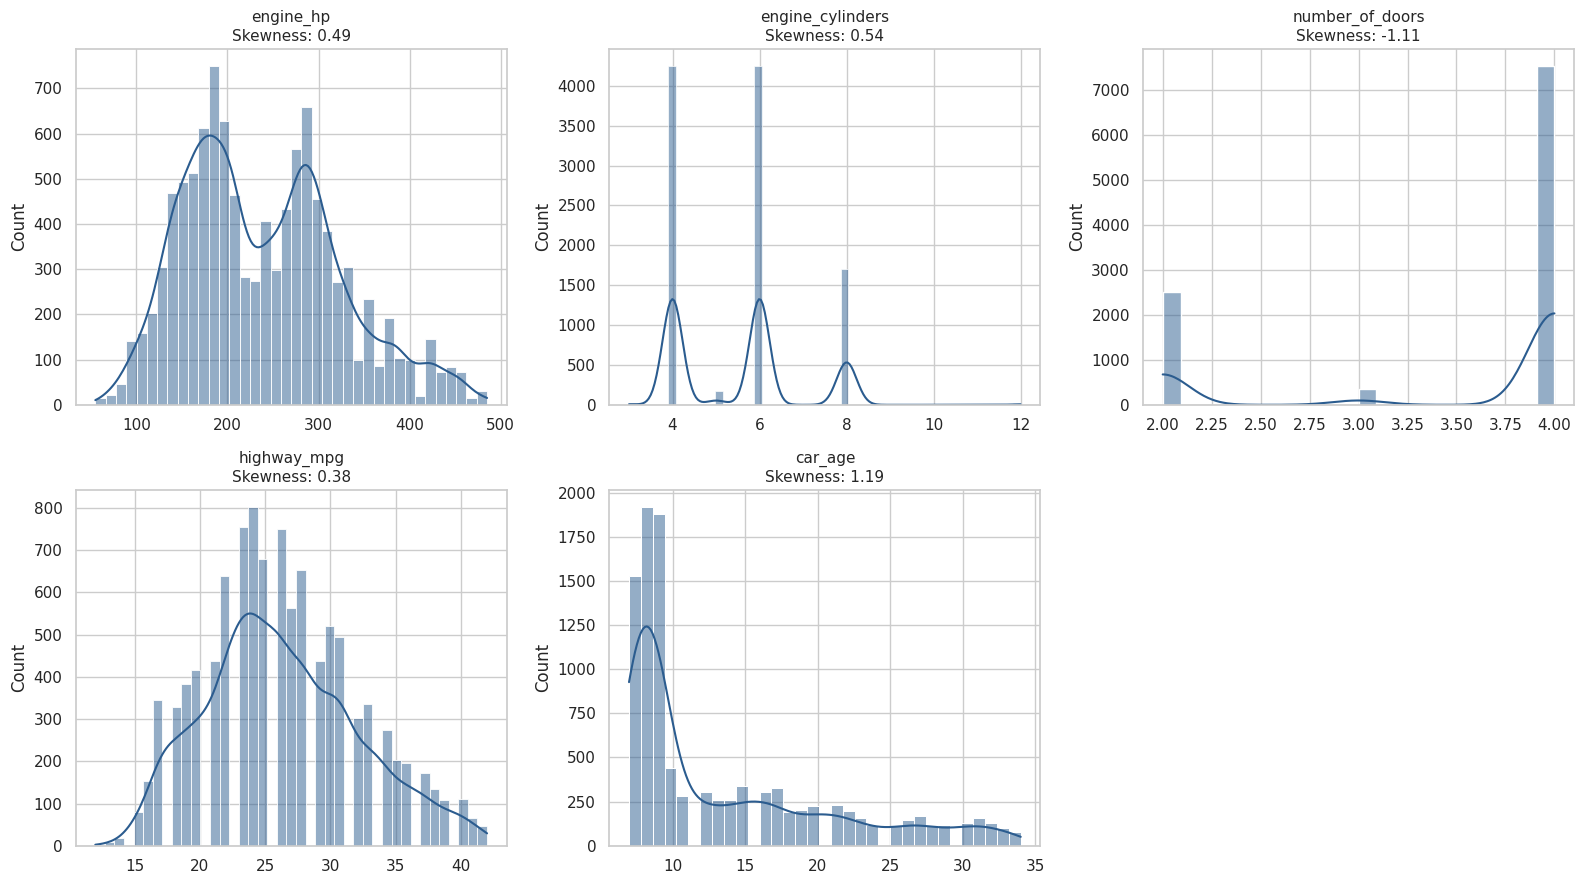

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for idx, col in enumerate(numeric_features):
    row, col_idx = divmod(idx, 3)
    skew_val = df_clean[col].skew()

    sns.histplot(df_clean[col], kde=True, ax=axes[row, col_idx], color="#2b5c8f")
    axes[row, col_idx].set_title(
        f"{col}\nSkewness: {skew_val:.2f}", fontsize=11
    )
    axes[row, col_idx].set_xlabel("")


axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

# Comparative Evaluation: Linear Regression, Random Forest, and HistGradientBoosting

In [126]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    VotingRegressor,
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler


df_enhanced = df_clean.copy()

df_enhanced["hp_per_cylinder"] = (
    df_enhanced["engine_hp"] / df_enhanced["engine_cylinders"]
)


df_enhanced["hp_age_ratio"] = df_enhanced["engine_hp"] / (
    df_enhanced["car_age"] + 1
)


luxury_brands = [
    "BMW",
    "Mercedes-Benz",
    "Audi",
    "Porsche",
    "Bentley",
    "Aston Martin",
    "Ferrari",
    "Lamborghini",
    "Maserati",
    "Land Rover",
    "Lexus",
    "Rolls-Royce",
]
df_enhanced["is_luxury"] = (
    df_enhanced["make"].isin(luxury_brands).astype(int)
)


X = df_enhanced.drop(columns=["msrp"])
y = np.log1p(df_enhanced["msrp"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


skewed_feature = ["car_age", "hp_age_ratio"]
normal_numeric_features = [
    "engine_hp",
    "engine_cylinders",
    "number_of_doors",
    "highway_mpg",
    "hp_per_cylinder",
    "is_luxury",
]
categorical_features = [
    "make",
    "engine_fuel_type",
    "transmission_type",
    "driven_wheels",
    "vehicle_size",
    "vehicle_style",
]


skewed_pipe = Pipeline(
    [("log", FunctionTransformer(np.log1p)), ("scaler", StandardScaler())]
)

numeric_pipe = Pipeline([("scaler", StandardScaler())])

categorical_pipe = Pipeline(
    [("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("skew", skewed_pipe, skewed_feature),
        ("num", numeric_pipe, normal_numeric_features),
        ("cat", categorical_pipe, categorical_features),
    ]
)


tuned_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=25,
    min_samples_split=4,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
)


tuned_hgb = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=45,
    l2_regularization=2.0,
    random_state=42,
)


ensemble_voting = VotingRegressor(
    estimators=[("rf", tuned_rf), ("hgb", tuned_hgb)], weights=[0.55, 0.45]
)

models = {
    "Linear Regression (Baseline)": LinearRegression(),
    "Random Forest (Tuned)": tuned_rf,
    "HistGradientBoosting (Tuned)": tuned_hgb,
    "Ensemble (RF + HGB)": ensemble_voting,
}


results = []
trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])

    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe

    y_pred_log = pipe.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    results.append(
        {
            "Model": name,
            "MAE ($)": f"${mae:,.2f}",
            "RMSE ($)": f"${rmse:,.2f}",
            "R2 Score": round(r2, 4),
        }
    )

results_df = pd.DataFrame(results)
results_df

,Model,MAE ($),RMSE ($),R2 Score
0,Linear Regression (Baseline),"$9,303.23","$13,530.35",0.6522
1,Random Forest (Tuned),"$2,637.08","$5,159.32",0.9494
2,HistGradientBoosting (Tuned),"$2,661.75","$5,008.33",0.9523
3,Ensemble (RF + HGB),"$2,582.85","$4,947.44",0.9535


In [127]:
import joblib

best_ensemble = trained_pipelines['Ensemble (RF + HGB)']
joblib.dump(best_ensemble, 'car_price_ensemble_model.joblib')
print("Successfully exported the trained Ensemble model pipeline to 'car_price_ensemble_model.joblib'!")

Successfully exported the trained Ensemble model pipeline to 'car_price_ensemble_model.joblib'!
